In [56]:
import networkx as nx
from cdlib.algorithms import leiden, louvain, infomap, walktrap
from time import time
import numpy as np
import math

In [2]:
def tic():
    return time()

def toc(start):
    return time() - start

In [3]:
G = nx.read_graphml("KRvKP_7_updated.graphml")
G = nx.convert_node_labels_to_integers(G)
print(f"n: {G.number_of_nodes()}")
print(f"m: {G.number_of_edges()}")

n: 177557
m: 1017308


In [4]:
def save(G, filename):
    reverse_map = {node_id: data["label"] for node_id, data in G.nodes(data=True)}
    G_restored = nx.relabel_nodes(G, reverse_map)
    nx.write_graphml(G, f"{filename}.graphml")

In [5]:
def set_communities_to_graph(G, communities, algorithm_name):
    for i, c in enumerate(communities):
        for u in c:
            G.nodes[u][algorithm_name] = i

#algorithms = {"louvain": louvain, "leiden": leiden, "infomap": infomap, "walktrap": walktrap}
algorithms = {"leiden": leiden}
results = {k: None for k in algorithms.keys()}

for algorithm_name, algorithm in algorithms.items():
    start = tic()
    try:
        result = algorithm(G)
        set_communities_to_graph(G, result.communities, algorithm_name)
    except TypeError as e:
        G_ = G.to_undirected()
        result = algorithm(G_)
        set_communities_to_graph(G, result.communities, algorithm_name)
    results[algorithm_name] = result
    t = toc(start)
    print(f"{algorithm_name}: {t:.2f}s")

leiden: 16.68s


In [6]:
save(G, "KRvKP_7_updated_updated")

In [7]:
G.nodes[0]

{'label': '3r4/2k5/5P2/7K/8/8/8/8:b:2',
 'wdl': 2,
 'Cluster': 0,
 'Inferred Class': 0,
 'size': 4.0,
 'r': 0,
 'g': 106,
 'b': 111,
 'x': -349.77667,
 'y': -11541.133,
 'leiden': 0}

In [20]:
win_frequency = dict()
loss_frequency = dict()
draw_frequency = dict()

nodes = list(G.nodes())

result = results["leiden"]
communities = result.communities
communities = {i: c for i, c in enumerate(communities) if len(c)/len(nodes) >= 0.01}

for i, c in communities.items():
    wins = 0
    losses = 0
    draws = 0
    for u in c:
        if G.nodes[u]["wdl"] == 2:
            wins += 1
        elif G.nodes[u]["wdl"] == -2:
            losses += 1
        elif G.nodes[u]["wdl"] == 0:
            draws += 1
    win_frequency[i] = wins/len(c)
    loss_frequency[i] = losses/len(c)
    draw_frequency[i] = draws/len(c)

In [21]:
win_frequency = dict(sorted(win_frequency.items(), key=lambda item: -item[1]))
loss_frequency = dict(sorted(loss_frequency.items(), key=lambda item: -item[1]))
draw_frequency = dict(sorted(draw_frequency.items(), key=lambda item: -item[1]))

In [22]:
draw_frequency

{28: 0.9790402647545504,
 26: 0.948509485094851,
 10: 0.8473309608540925,
 11: 0.7655476059438635,
 8: 0.6464484249536752,
 12: 0.5965873183062987,
 5: 0.5592768571097462,
 4: 0.5564386086155264,
 24: 0.5257787325456499,
 6: 0.5224157955865273,
 7: 0.5070522697641342,
 2: 0.5020627062706271,
 3: 0.4718365504007224,
 15: 0.45511811023622045,
 21: 0.44670846394984326,
 14: 0.40967117988394586,
 18: 0.34979633401221993,
 30: 0.25806451612903225,
 0: 0.23903743315508022,
 20: 0.20878552971576228,
 29: 0.1875,
 13: 0.10970959225579349,
 19: 0.10810810810810811,
 16: 0.10666666666666667,
 9: 0.07422334172963896,
 22: 0.06958355297838692,
 27: 0.057003257328990226,
 25: 0.05180787911494873,
 17: 0.0337573385518591,
 23: 0.03208556149732621,
 1: 0.010199263386533194}

In [23]:
win_frequency

{17: 0.9329745596868885,
 13: 0.8899970665884424,
 27: 0.8697068403908795,
 9: 0.836272040302267,
 19: 0.815910249872514,
 30: 0.6590656284760845,
 0: 0.654367201426025,
 23: 0.5411764705882353,
 22: 0.4881391671059568,
 25: 0.48300053966540746,
 29: 0.42367256637168144,
 2: 0.41759488448844884,
 24: 0.416219119226638,
 20: 0.3689922480620155,
 12: 0.3140931114388035,
 18: 0.23828920570264767,
 11: 0.22876536415336635,
 3: 0.22530759679422058,
 7: 0.19805618110702858,
 6: 0.17038327526132405,
 4: 0.1597558166321124,
 10: 0.15231316725978647,
 5: 0.14335380693011937,
 1: 0.1342903012560204,
 8: 0.1314391599752934,
 14: 0.09864603481624758,
 21: 0.08254963427377221,
 15: 0.07244094488188976,
 26: 0.051490514905149054,
 28: 0.020959735245449532,
 16: 0.0}

In [24]:
loss_frequency

{16: 0.8933333333333333,
 1: 0.8555104353574464,
 14: 0.4916827852998066,
 15: 0.47244094488188976,
 21: 0.47074190177638453,
 25: 0.4651915812196438,
 22: 0.4422772799156563,
 23: 0.4267379679144385,
 20: 0.4222222222222222,
 18: 0.4119144602851324,
 29: 0.38882743362831856,
 6: 0.30720092915214864,
 3: 0.302855852805057,
 5: 0.29736933596013443,
 7: 0.29489154912883725,
 4: 0.28380557475236123,
 8: 0.2221124150710315,
 0: 0.10659536541889483,
 9: 0.08950461796809404,
 12: 0.08931957025489783,
 30: 0.0828698553948832,
 2: 0.08034240924092409,
 19: 0.07598164201937786,
 27: 0.0732899022801303,
 24: 0.05800214822771214,
 17: 0.033268101761252444,
 11: 0.0056870299027701335,
 10: 0.00035587188612099647,
 13: 0.0002933411557641537,
 26: 0.0,
 28: 0.0}

In [14]:
def get_barycenter(G, community):
    G_ = G.subgraph(community)
    G_ = G_.to_undirected()
    return nx.barycenter(G_)[0]

In [67]:
barycenter = get_barycenter(G, result.communities[13])

In [68]:
G.nodes[barycenter]

{'label': '3r4/2k5/5P2/8/5K2/8/8/8:b:2',
 'wdl': 2,
 'Modularity Class': 0,
 'Inferred Class': 17,
 'Cluster': 7,
 'size': 10.0,
 'r': 255,
 'g': 87,
 'b': 255,
 'x': 531.94666,
 'y': 2833.6394,
 'louvain': 12,
 'leiden': 13,
 'infomap': 4,
 'walktrap': 6}

In [15]:
def get_barycenters(G, communities):
    return {i: get_barycenter(G, c) for i, c in communities.items()}

def get_edges_between_communities(G, communities):
    skeleton_edges = {(i, j): set() for i in communities.keys() for j in communities.keys() if i != j}

    comm = {u: i for i, c in communities.items() for u in c}
    for (u, v) in G.edges():
        c_u = comm.get(u, None)
        c_v = comm.get(v, None)
        if c_u == c_v or c_u is None or c_v is None:
            continue

        skeleton_edges[(c_u, c_v)].add((u, v))

    return skeleton_edges

In [37]:
community_edges = get_edges_between_communities(G, communities)
community_edges

{(0, 1): {(132834, 161228),
  (132846, 161228),
  (132858, 161228),
  (142693, 140382),
  (142712, 140382),
  (155561, 155564),
  (156894, 175585),
  (157005, 175585),
  (157059, 175585),
  (157096, 155564)},
 (0, 2): {(72575, 142841),
  (144593, 164619),
  (72587, 143898),
  (143725, 160788),
  (71023, 108098),
  (143735, 160838),
  (74002, 145274),
  (71008, 107597),
  (75184, 170355),
  (156027, 170375),
  (143645, 160944),
  (76398, 77021),
  (75310, 170351),
  (144612, 164754),
  (69095, 72732),
  (71013, 107532),
  (143761, 161384),
  (65553, 71287),
  (144746, 164754),
  (73933, 145934),
  (104549, 127520),
  (156816, 173015),
  (71026, 108145),
  (105490, 128223),
  (73930, 145928),
  (105446, 128296),
  (73877, 145364),
  (72336, 142716),
  (75188, 170855),
  (144755, 164838),
  (76318, 76884),
  (63536, 66171),
  (67384, 105566),
  (73976, 144848),
  (73812, 145091),
  (106417, 156842),
  (63221, 69579),
  (144659, 164986),
  (63552, 69678),
  (144619, 164770),
  (144644, 164

In [17]:
barycenters = get_barycenters(G, communities)
barycenters

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\Matej\.conda\envs\chess-ao\Lib\site-packages\IPython\core\interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Matej\AppData\Local\Temp\ipykernel_24304\3955639047.py", line 1, in <module>
    barycenters = get_barycenters(G, communities)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Matej\AppData\Local\Temp\ipykernel_24304\802767926.py", line 2, in get_barycenters
    return {i: get_barycenter(G, c) for i, c in communities.items()}
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Matej\AppData\Local\Temp\ipykernel_24304\802767926.py", line 2, in <dictcomp>
    return {i: get_barycenter(G, c) for i, c in communities.items()}
               ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Matej\AppData\Local\Temp\ipykernel_24304\3791969002.py", line 4, in get_barycenter
    return nx.barycenter(G_)[0]
           ^^^^^^^^^^^^^^^^

In [38]:
def get_community_graph(G, communities):
    #barycenters = get_barycenters(G, communities)
    community_edges = get_edges_between_communities(G, communities)

    G_community = nx.DiGraph()

    for (c_u, c_v), edges in community_edges.items():
        if len(edges) >= 1:
            G_community.add_edge(c_u, c_v)

    for i, c in communities.items():
        u = c[0]
        G_community.nodes[i]["x"] = G.nodes[u]["x"]
        G_community.nodes[i]["y"] = G.nodes[u]["y"]
    
    return G_community

def draw_community_graph(G_community, communities):
    pos = dict()
    for u, data in G_community.nodes(data=True):
        x = data["x"]
        y = data["y"]
        pos[u] = (x, y)
        
    comm = {u: i for i, c in communities.items() for u in c}
    node_colors = []
    for c in G_community.nodes():
        w = win_frequency.get(c, 0)
        l = loss_frequency.get(c, 0)
        d = draw_frequency.get(c, 0)
    
        wl = w + l
    
        r = l / wl
        g = w / wl
    
        r = r * (1 - d)
        g = g * (1 - d)
        
        node_colors.append((r, g, 0))
        
    return nx.draw(G_community, pos=pos, node_color=node_colors, with_labels=True, font_color="white")

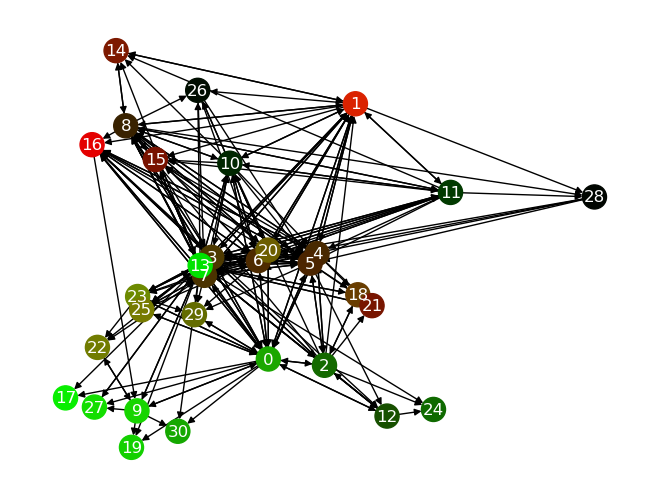

In [39]:
G_community = get_community_graph(G, communities)
draw_community_graph(G_skeleton, communities)

In [108]:
start_node = 0 # 3r4/2k5/5P2/7K/8/8/8/8:b:2 <=> 3r4/2k5/5P2/7K/8/8/8/8 b - - 0 1
all_paths = nx.single_source_shortest_path(G, source=start_node)
barycenter_paths = {}

for comm_i, barycenter in barycenters.items():
    path = all_paths[barycenter]
    barycenter_paths[comm_i] = path

In [110]:
barycenter_paths

{0: [0, 1, 19163, 1893],
 1: [0, 1, 19181, 3912],
 2: [0, 2, 19501, 42],
 3: [0, 1, 19181, 3912, 4545],
 4: [0, 2, 19143, 2576, 1065],
 5: [0, 1, 19181, 3912, 4546],
 6: [0, 1, 19163, 1893, 1066],
 7: [0, 1, 19147, 2608, 1064],
 8: [0, 1, 19181, 3912, 1063],
 9: [0, 2, 19180, 3928, 1062],
 10: [0],
 11: [0, 1, 19163, 1893, 2892],
 12: [0, 1, 19147, 2608, 2889],
 13: [0, 1, 19163, 1893, 2890],
 14: [0, 1, 19163, 1893, 2891],
 15: [0, 1, 19181, 3912, 4547],
 16: [0, 1, 19181, 3912, 2887],
 17: [0, 2, 19501, 42, 1070],
 18: [0, 2, 19501, 42, 1069]}

In [31]:
# 1 - W + L
def get_community_scores():
    community_scores = dict()
    for comm_i in win_frequency.keys():
        w = win_frequency[comm_i]
        l = loss_frequency[comm_i]
        
        score = 1 - w + l
        community_scores[comm_i] = score
    return community_scores

In [35]:
def Q_norm(communities, alpha, win_frequency, loss_frequency, draw_frequency):
    Q = dict()
    
    for i, c in communities.items():
        w = win_frequency[i]
        d = draw_frequency[i]
        Q[i] = w + (1 - alpha) * d
        
    return Q     

In [33]:
# best/ideal community (by get_community_scores) to get to is 13
community_scores = get_community_scores()
community_scores = dict(sorted(community_scores.items(), key=lambda item: -item[1]))
community_scores

{16: 1.8933333333333333,
 1: 1.7212201341014262,
 15: 1.4,
 14: 1.393036750483559,
 21: 1.3881922675026124,
 18: 1.1736252545824848,
 5: 1.1540155290300151,
 6: 1.1368176538908246,
 4: 1.1240497581202487,
 7: 1.0968353680218086,
 8: 1.090673255095738,
 3: 1.0775482560108363,
 20: 1.0532299741602067,
 25: 0.9821910415542363,
 28: 0.9790402647545504,
 29: 0.9651548672566372,
 22: 0.9541381128096995,
 26: 0.948509485094851,
 23: 0.8855614973262033,
 10: 0.8480427046263345,
 11: 0.7769216657494038,
 12: 0.7752264588160943,
 2: 0.6627475247524752,
 24: 0.6417830290010741,
 0: 0.4522281639928698,
 30: 0.4238042269187987,
 19: 0.2600713921468638,
 9: 0.2532325776658271,
 27: 0.20358306188925077,
 13: 0.1102962745673218,
 17: 0.10029354207436397}

In [36]:
# best/ideal community (by get_community_scores) to get to is 13
alpha = 0.5
Q = Q_norm(communities, alpha, win_frequency, loss_frequency, draw_frequency)
Q = dict(sorted(Q.items(), key=lambda item: -item[1]))
Q

{17: 0.949853228962818,
 13: 0.9448518627163391,
 27: 0.8982084690553747,
 9: 0.8733837111670865,
 19: 0.8699643039265681,
 30: 0.7880978865406006,
 0: 0.7738859180035651,
 24: 0.6791084854994629,
 2: 0.6686262376237624,
 12: 0.6123867705919528,
 11: 0.6115391671252981,
 10: 0.5759786476868327,
 23: 0.5572192513368983,
 26: 0.5257452574525745,
 22: 0.5229309435951502,
 29: 0.5174225663716814,
 28: 0.5104798676227248,
 25: 0.5089044792228818,
 20: 0.47338501291989665,
 3: 0.46122587199458176,
 8: 0.45466337245213095,
 7: 0.4515823159890957,
 4: 0.4379751209398756,
 6: 0.4315911730545877,
 5: 0.42299223548499243,
 18: 0.4131873727087576,
 21: 0.3059038662486938,
 14: 0.3034816247582205,
 15: 0.3,
 1: 0.139389932949287,
 16: 0.05333333333333334}

In [57]:
def log_metric(node):
    epsilon = 1e-9
    q_safe = max(epsilon, min(1.0, Q[node]))
    return -math.log(q_safe)

In [60]:
def apply_edge_weights(G, metric_func):
    for u, v in G.edges():
        weight = metric_func(v)
        G[u][v]["weight"] = weight

In [61]:
apply_edge_weights(G_community, log_metric)

In [62]:
costs, paths = nx.single_source_dijkstra(G_community, source=G.nodes[0]["leiden"], weight="weight")

In [63]:
costs

{0: 0,
 17: 0.05144780215187307,
 13: 0.05672712280670423,
 27: 0.10735308945358522,
 9: 0.13538028801632804,
 19: 0.13930309814472183,
 30: 0.23813297534088518,
 2: 0.4025300631341,
 24: 0.44370151453369683,
 12: 0.4903912179924422,
 11: 0.5485033978128704,
 10: 0.5516846889614925,
 23: 0.5847964875353202,
 29: 0.6588953952379776,
 25: 0.6754949436519022,
 26: 0.6996656077839033,
 22: 0.7050329854568457,
 20: 0.7478462407897519,
 3: 0.773867395034465,
 8: 0.7881979746129749,
 7: 0.79499760604488,
 4: 0.8255931717260909,
 6: 0.8402764974880473,
 5: 0.8604014559317704,
 18: 0.9405812247664695,
 28: 1.2209074765541692,
 21: 1.2412115117818319,
 14: 1.2491613375761466,
 15: 1.2606999271326405,
 1: 1.9704800002700367,
 16: 2.9311937524164198}

In [64]:
paths

{0: [0],
 17: [0, 17],
 13: [0, 13],
 27: [0, 27],
 9: [0, 9],
 19: [0, 19],
 30: [0, 30],
 2: [0, 2],
 24: [0, 13, 24],
 12: [0, 12],
 11: [0, 13, 11],
 10: [0, 10],
 23: [0, 23],
 29: [0, 29],
 25: [0, 25],
 26: [0, 13, 26],
 22: [0, 13, 22],
 20: [0, 20],
 3: [0, 3],
 8: [0, 8],
 7: [0, 7],
 4: [0, 4],
 6: [0, 6],
 5: [0, 5],
 18: [0, 13, 18],
 28: [0, 13, 11, 28],
 21: [0, 13, 21],
 14: [0, 13, 14],
 15: [0, 13, 15],
 1: [0, 1],
 16: [0, 16]}